# RANSAC

Let's Implement (some of) RANSAC!

First, you will have to fit a line to some data points. Here's how to accomplish that:

<img src="fitting_a_line.png" width="400">

(The function `np.linalg.lstsq` is what you want here: `beta = np.linalg.lstsq(x_matrix, y_vector)[0]`, but you will need to construct `x_matrix`.)

I have provided you with some code that confirms that the Chi-Squared threshold does what we expect: 95% of the points generated by a Gaussian distribution are within the threshold specified for each dimensionality.

I have also included some code that generates linear data (with some noise and a few added outliers). Write a function that fits a line to the data. Then, using this function, use the RANSAC procedure to fit a line to the data that excludes (most) outliers. The RANSAC procedure works as follows:

- Iteratively (over $N$ rounds):
  - Pick a sample of $s$ points from all the data points
  - Fit a line to those $s$ points
  - Count the number of inliers using the Chi-Squared threshold
- Pick the model parameters ($\hat{m}$ and $\hat{b}$) for the line with the most inliers.
- Retrain the model using all inliers from the best model.
- Return those updated model parameters.

How many *rounds* $N$ should you be running RANSAC before picking the best model? You can use this formula for the likelihood $p$ of picking an all-inlier model:

$$ p = 1 - \left( 1 - (1 - e)^s \right)^N $$

where $e$ is the outlier ratio and $s$ is the number of samples (matches) per round.

How well does RANSAC do under different conditions? What happens when the outlier ratio is above $0.5$?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def fit_line_to_data(xs, ys):
    raise NotImplementedError()
    
def compute_num_outliers(xs, ys, b, m, noise_sigma=0.5, chi_sq_thresh=3.84):
    return len(ys) - len(get_inliers(xs, ys, b, m, noise_sigma, chi_sq_thresh)[1])
    
def get_inliers(xs, ys, b, m, noise_sigma=0.5, chi_sq_thresh=3.84):
    raise NotImplementedError()
    
def plot_line(b, m, xrange=[-1, 6], num_points=100):
    xs = np.linspace(min(xrange), max(xrange), num_points)
    ys = m * xs + b
    plt.plot(xs, ys)

def get_signal_with_outliers(num_inliers=40, num_outliers=10, 
                             m=2.0, b=-1.5, noise_sigma=0.5, b_off=5.0,
                             xrange=[0, 5]):
    """Note that the 'num_outliers' may not be strictly accurate, 
    since I have simply used another model to generate those points
    and added them to the original set."""
    np.random.seed(682)
    N = num_inliers + num_outliers
    xs = min(xrange) + (max(xrange) - min(xrange)) * np.random.rand(N)
    noises = np.random.normal(scale=noise_sigma, size=N)
    outlier_noises = np.zeros(N)
    outlier_noises[:num_outliers] = b_off + np.random.normal(scale=6*noise_sigma, size=num_outliers)
    np.random.shuffle(outlier_noises)
    ys = m*xs + b + noises + outlier_noises
    return xs, ys


# Let's start by looking at the data
xs, ys = get_signal_with_outliers()
plt.plot(xs, ys, 'ko')
plot_line(b=-1.5, m=2.0)
plt.title("This is the line we want")

# TASK 1: Fit a line to this data
plt.figure()
b, m = fit_line_to_data(xs, ys)
plt.plot(xs, ys, 'ko')
plot_line(b, m)
plt.title("This is the line we've got")

# TASK 2: Compute the number of outliers by implementing get_inliers
num_outliers = compute_num_outliers(xs, ys, b, m)
print(f"Num Outliers (fit solution): {num_outliers}")
num_outliers = compute_num_outliers(xs, ys, b=-1.5, m=2.0)
print(f"Num Outliers (known solution): {num_outliers}")

# Plot the inliers
plt.figure()
xs_in, ys_in = get_inliers(xs, ys, b=-1.5, m=2.0)
plt.plot(xs, ys, 'ko')
plt.plot(xs_in, ys_in, 'rx')
plot_line(b=-1.5, m=2.0)
plt.title("This is the line we want + inliers")

plt.figure()
b, m = fit_line_to_data(xs, ys)
xs_in, ys_in = get_inliers(xs, ys, b=b, m=m)
plt.plot(xs, ys, 'ko')
plt.plot(xs_in, ys_in, 'rx')
plot_line(b, m)
plt.title("This is the line we fit + inliers")

# TASK 3: Implement RANSAC.

None

In [ ]:
# Show that the chi-squared threshold
# results in 95% inliers.

import numpy as np

d, chsq_thresh = 1, 3.84
# d, chsq_thresh = 2, 5.99
N = 10000
sigma = 2.0
residuals = np.random.normal(scale=sigma, size=[N, d])
sum_sq_residuals = np.sum(residuals**2, axis=1)
inlier_ratio = (
    (sum_sq_residuals <= chsq_thresh*(sigma**2))
    .astype(int)
    .sum()) / N
print(f"Inlier Ratio: {inlier_ratio:.4f} | "
      f"Outlier Ratio: {1-inlier_ratio:.4f}" )

# Plot the example data
if d == 1:
    plt.figure(figsize=(10, 3))
    xs = np.arange(N)
    plt.scatter(xs, residuals, color='b')

    xs_outliers = xs[sum_sq_residuals > chsq_thresh*(sigma**2)]
    outliers = residuals[sum_sq_residuals > chsq_thresh*(sigma**2)]
    plt.scatter(xs_outliers, outliers, color='r')
elif d == 2:
    plt.figure(figsize=(6, 6))
    plt.scatter(residuals[:, 0], residuals[:, 1], color='b')

    outliers = residuals[sum_sq_residuals > chsq_thresh*(sigma**2)]
    plt.scatter(outliers[:, 0], outliers[:, 1], color='r')

In [ ]:
#######################################################
#                Some Solutions Below                 #
#                  (No peeking yet)                   #
#######################################################

Num Outliers (fit solution): 32
Num Outliers (known solution): 9


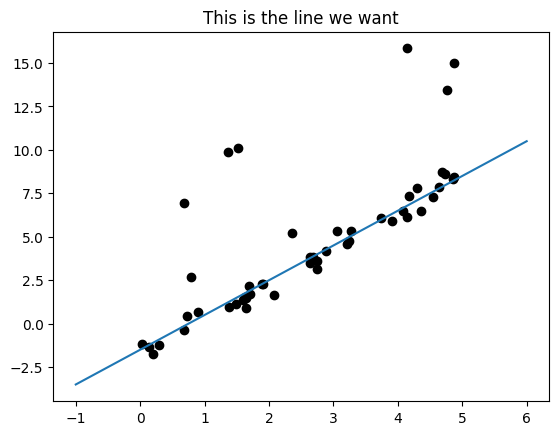

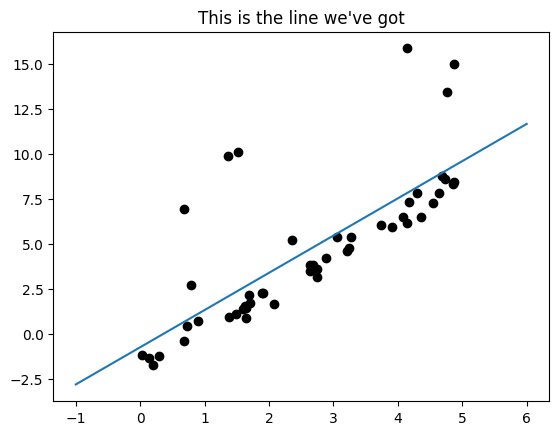

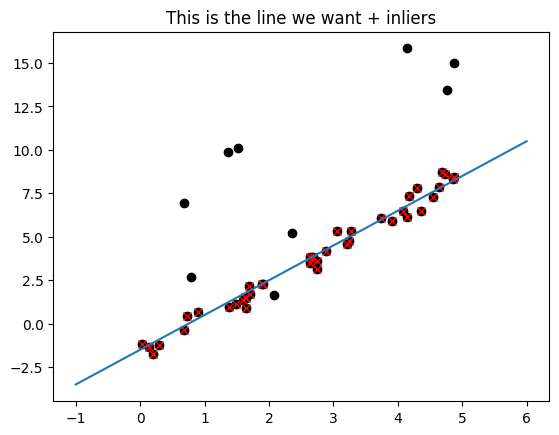

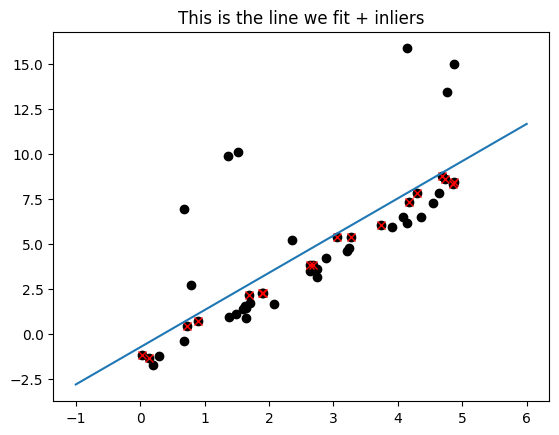

In [1]:
## Solution Code (from lecture)

import numpy as np
import matplotlib.pyplot as plt

def fit_line_to_data(xs, ys):
    XS = np.zeros((len(ys), 2))
    XS[:, 0] = 1
    XS[:, 1] = xs
    betas = np.linalg.lstsq(XS, ys)[0]
    return betas[0], betas[1]
    
def compute_num_outliers(xs, ys, b, m, noise_sigma=0.5, chi_sq_thresh=3.84):
    return len(ys) - len(get_inliers(xs, ys, b, m, noise_sigma, chi_sq_thresh)[1])
    
def get_inliers(xs, ys, b, m, noise_sigma=0.5, chi_sq_thresh=3.84):
    residuals = (m * xs + b) - ys
    inlier_mask = (residuals ** 2) < chi_sq_thresh * (noise_sigma ** 2)
    return xs[inlier_mask], ys[inlier_mask]
    
def plot_line(b, m, xrange=[-1, 6], num_points=100):
    xs = np.linspace(min(xrange), max(xrange), num_points)
    ys = m * xs + b
    plt.plot(xs, ys)

def get_signal_with_outliers(num_inliers=40, num_outliers=10, 
                             m=2.0, b=-1.5, noise_sigma=0.5, b_off=5.0,
                             xrange=[0, 5]):
    """Note that the 'num_outliers' may not be strictly accurate, 
    since I have simply used another model to generate those points
    and added them to the original set."""
    np.random.seed(682)
    N = num_inliers + num_outliers
    xs = min(xrange) + (max(xrange) - min(xrange)) * np.random.rand(N)
    noises = np.random.normal(scale=noise_sigma, size=N)
    outlier_noises = np.zeros(N)
    outlier_noises[:num_outliers] = b_off + np.random.normal(scale=6*noise_sigma, size=num_outliers)
    np.random.shuffle(outlier_noises)
    ys = m*xs + b + noises + outlier_noises
    return xs, ys


# Let's start by looking at the data
xs, ys = get_signal_with_outliers()
plt.plot(xs, ys, 'ko')
plot_line(b=-1.5, m=2.0)
plt.title("This is the line we want")

# TASK 1: Fit a line to this data
plt.figure()
b, m = fit_line_to_data(xs, ys)
plt.plot(xs, ys, 'ko')
plot_line(b, m)
plt.title("This is the line we've got")

# TASK 2: Compute the number of outliers by implementing get_inliers
num_outliers = compute_num_outliers(xs, ys, b, m)
print(f"Num Outliers (fit solution): {num_outliers}")
num_outliers = compute_num_outliers(xs, ys, b=-1.5, m=2.0)
print(f"Num Outliers (known solution): {num_outliers}")

# Plot the inliers
plt.figure()
xs_in, ys_in = get_inliers(xs, ys, b=-1.5, m=2.0)
plt.plot(xs, ys, 'ko')
plt.plot(xs_in, ys_in, 'rx')
plot_line(b=-1.5, m=2.0)
plt.title("This is the line we want + inliers")

plt.figure()
b, m = fit_line_to_data(xs, ys)
xs_in, ys_in = get_inliers(xs, ys, b=b, m=m)
plt.plot(xs, ys, 'ko')
plt.plot(xs_in, ys_in, 'rx')
plot_line(b, m)
plt.title("This is the line we fit + inliers")

# TASK 3: Implement RANSAC.

None